<a href="https://colab.research.google.com/github/FtomaMarzaq/S8_CAC_G2_22007263/blob/main/CAC%202%20-%20ML%20BLAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_590/612147845.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Données téléchargées : 756 lignes.
Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696648  72.455966  71.472469  71.629153  146322800
2020-01-06  72.267921  72.306491  70.568495  70.819193  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200

--- Résultats du Modèle ---
Erreur Quadratique Moyenne (MSE) : 9.28
Coefficient de détermination (R²) : 0.9910
Coeficients du modèle : [-8.88970270e-01  9.00453525e-01  9.82852924e-01  5.87338844e-10]
Ordonnée à l'origine : 0.8263181137042892


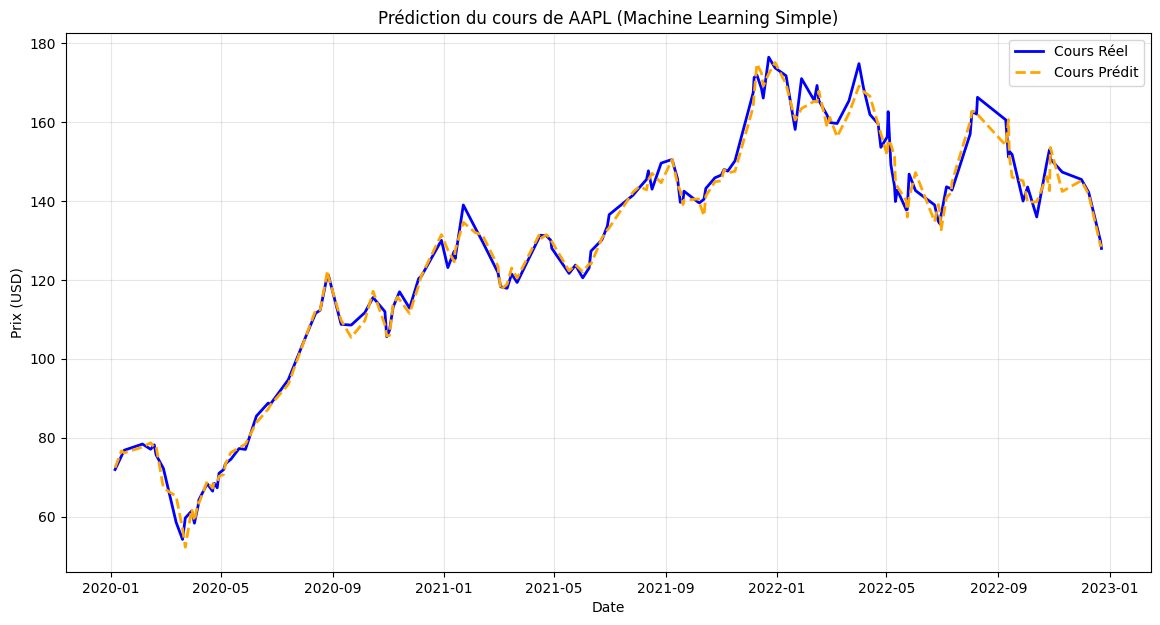

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ---------------------------------------------------------
# On télécharge les données historiques de l'action Apple (AAPL)
# Période : 1er Janvier 2020 au 1er Janvier 2023
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2023-01-01")

# Gestion des colonnes (yfinance renvoie parfois un MultiIndex)
# Si les colonnes sont un tuple ('Close', 'AAPL'), on les aplatit
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Vérification des données manquantes
data.dropna(inplace=True)

print(f"Données téléchargées : {len(data)} lignes.")
print(data.head())

# ---------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES (FEATURE ENGINEERING)
# ---------------------------------------------------------
# On crée notre variable cible (Target) : le cours de clôture du JOUR SUIVANT
# On décale la colonne 'Close' de -1 vers le haut
data['Target'] = data['Close'].shift(-1)

# On supprime la dernière ligne car elle n'a pas de cible (futur inconnu)
data = data[:-1]

# Sélection des caractéristiques (Features) pour l'entraînement
# On utilise : Ouverture, Plus haut, Plus bas, Volume
features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Target']


# ---------------------------------------------------------
# 3. SÉPARATION ENTRAINEMENT / TEST
# ---------------------------------------------------------
# On sépare les données : 80% pour entraîner, 20% pour tester
# random_state=42 assure la reproductibilité du résultat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT DU MODÈLE
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. PRÉDICTION ET ÉVALUATION
# ---------------------------------------------------------
# On fait des prédictions sur l'ensemble de test
predictions = model.predict(X_test)

# Calcul des métriques de performance
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Résultats du Modèle ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")
print(f"Coeficients du modèle : {model.coef_}")
print(f"Ordonnée à l'origine : {model.intercept_}")

# ---------------------------------------------------------
# 6. VISUALISATION (GRAPHIQUE)
# ---------------------------------------------------------
# Pour le graphique, on aligne les index de temps
# On crée un DataFrame pour comparer facilement
results_df = pd.DataFrame({'Date': X_test.index, 'Réel': y_test, 'Prédit': predictions})
results_df.sort_index(inplace=True)

plt.figure(figsize=(14, 7))
plt.plot(results_df['Date'], results_df['Réel'], label='Cours Réel', color='blue', linewidth=2)
plt.plot(results_df['Date'], results_df['Prédit'], label='Cours Prédit', color='orange', linestyle='--', linewidth=2)

plt.title(f'Prédiction du cours de {ticker} (Machine Learning Simple)')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

# Sauvegarde optionnelle du graphique
# plt.savefig('prediction_aapl.png')

plt.show()

## Exemple 2

/tmp/ipykernel_3138/2050260863.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Données téléchargées : 756 lignes.
Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200

Nombre de features utilisées : 12
Features : ['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_10', 'MA_20', 'Volatility_5', 'Range', 'Position', 'Momentum_5', 'Momentum_10']

--- Entraînement du modèle Random Forest ---

--- Résultats du Modèle Random Forest ---
Erreur Quadratique Moyenne (MSE) : 8.87
Racine de l'Erreur Quadratique Moyenne (RMSE) : 2.98
Erreur Absolue Moyenne (MAE) : 2.21
Coefficient de détermination (R²) : 0.9904

--- Importance des Features ---
         feature  importance
1       

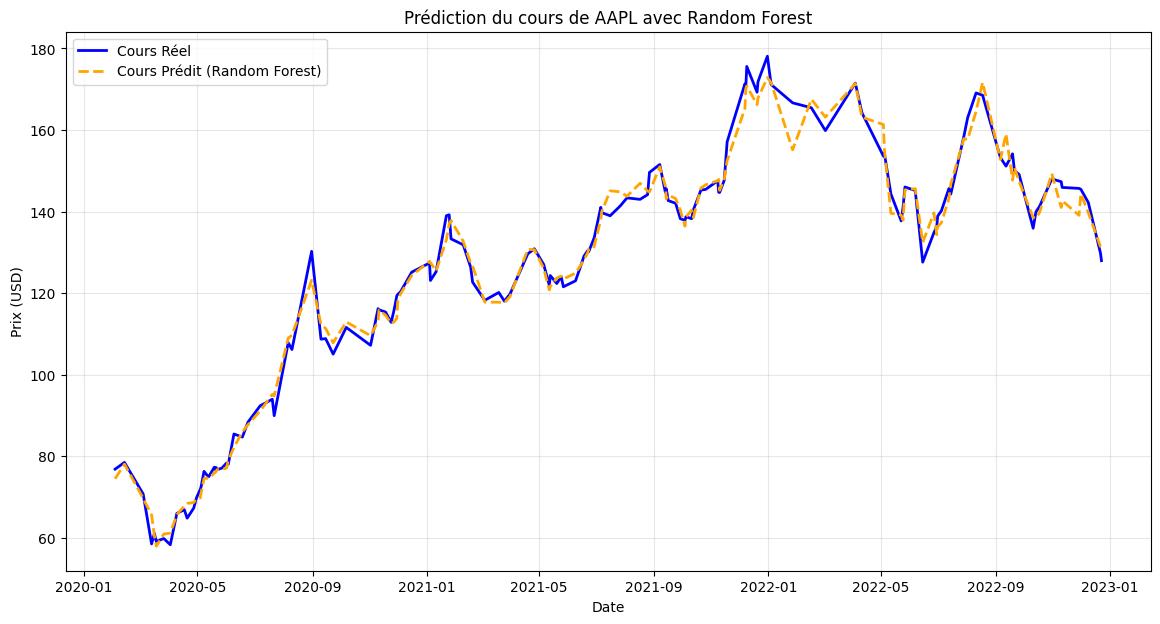

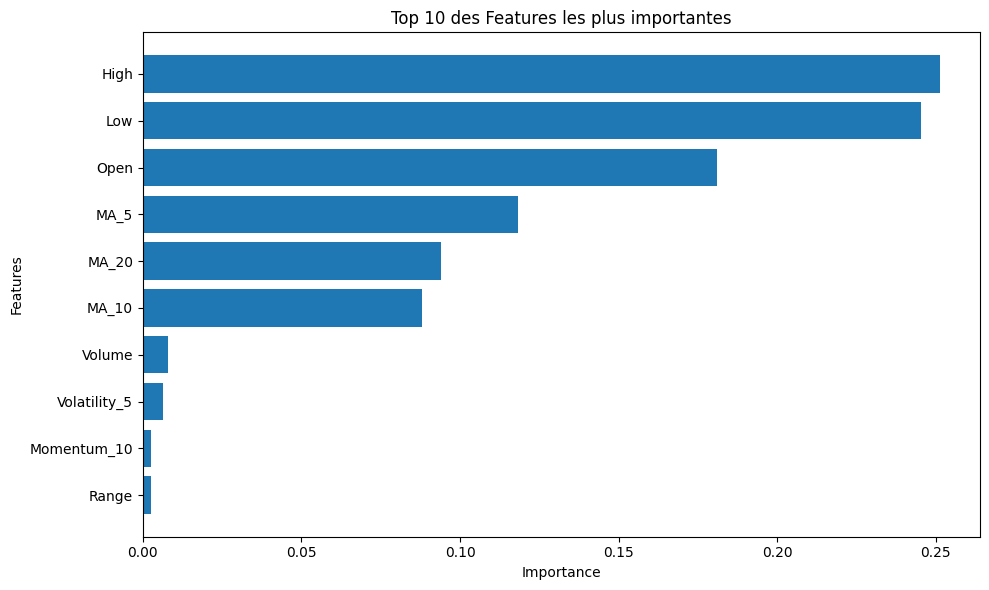

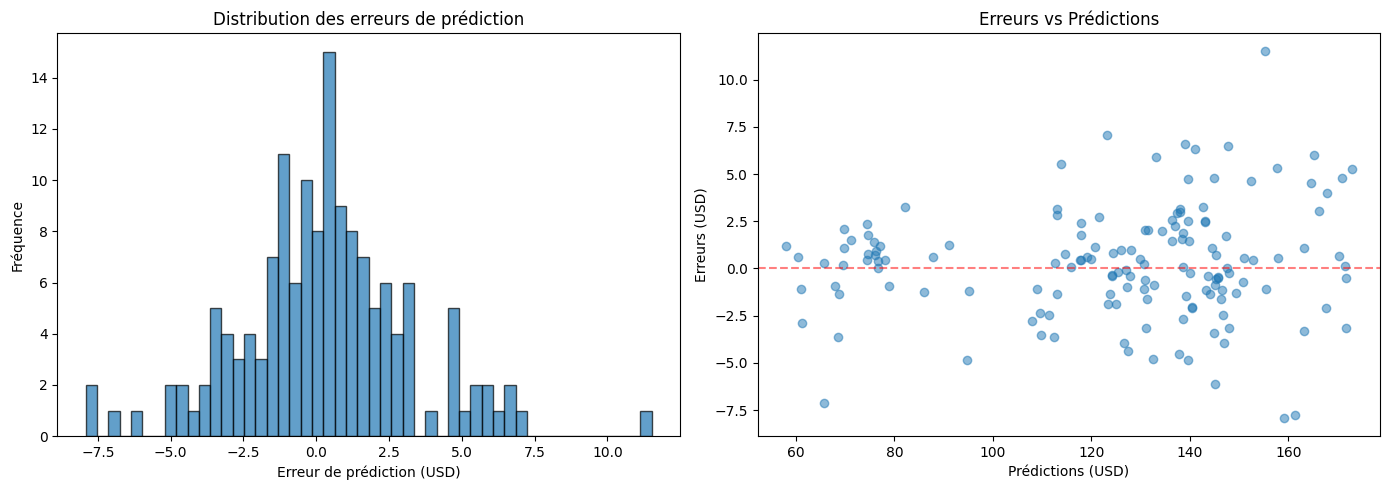


--- Statistiques des erreurs ---
Erreur moyenne : 0.27 USD
Écart-type des erreurs : 2.98 USD
Erreur maximale positive : 11.51 USD
Erreur maximale négative : -7.92 USD


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ---------------------------------------------------------
# On télécharge les données historiques de l'action Apple (AAPL)
# Période : 1er Janvier 2020 au 1er Janvier 2023
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2023-01-01")

# Gestion des colonnes (yfinance renvoie parfois un MultiIndex)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Vérification des données manquantes
data.dropna(inplace=True)

print(f"Données téléchargées : {len(data)} lignes.")
print(data.head())

# ---------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES (FEATURE ENGINEERING)
# ---------------------------------------------------------
# On crée notre variable cible (Target) : le cours de clôture du JOUR SUIVANT
data['Target'] = data['Close'].shift(-1)

# On supprime la dernière ligne car elle n'a pas de cible (futur inconnu)
data = data[:-1]

# Création de features supplémentaires pour améliorer le modèle Random Forest
# Features de base
features = ['Open', 'High', 'Low', 'Volume']

# Ajout de features techniques
# 1. Moyennes mobiles
data['MA_5'] = data['Close'].rolling(window=5).mean()
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()

# 2. Volatilité (écart-type des rendements sur 5 jours)
data['Returns'] = data['Close'].pct_change()
data['Volatility_5'] = data['Returns'].rolling(window=5).std()

# 3. Range (High - Low) normalisé
data['Range'] = (data['High'] - data['Low']) / data['Close']

# 4. Position dans la journée (Close par rapport à High-Low)
data['Position'] = (data['Close'] - data['Low']) / (data['High'] - data['Low'])

# 5. Momentum (différence de prix sur différentes périodes)
data['Momentum_5'] = data['Close'] - data['Close'].shift(5)
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)

# Ajout des nouvelles features à la liste
additional_features = ['MA_5', 'MA_10', 'MA_20', 'Volatility_5', 'Range', 'Position', 'Momentum_5', 'Momentum_10']
features.extend(additional_features)

# Suppression des lignes avec des valeurs NaN créées par les calculs de features
data.dropna(inplace=True)

# Sélection des caractéristiques (Features) pour l'entraînement
X = data[features]
y = data['Target']

print(f"\nNombre de features utilisées : {len(features)}")
print(f"Features : {features}")

# ---------------------------------------------------------
# 3. SÉPARATION ENTRAINEMENT / TEST
# ---------------------------------------------------------
# On sépare les données : 80% pour entraîner, 20% pour tester
# random_state=42 assure la reproductibilité du résultat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT DU MODÈLE RANDOM FOREST
# ---------------------------------------------------------
# Création du modèle Random Forest avec des hyperparamètres optimisés
model = RandomForestRegressor(
    n_estimators=100,           # Nombre d'arbres dans la forêt
    max_depth=15,               # Profondeur maximale des arbres
    min_samples_split=5,        # Nombre minimum d'échantillons pour diviser un nœud
    min_samples_leaf=2,         # Nombre minimum d'échantillons dans une feuille
    max_features='sqrt',        # Nombre de features à considérer pour la meilleure division
    random_state=42,            # Pour la reproductibilité
    n_jobs=-1                   # Utiliser tous les processeurs disponibles
)

print("\n--- Entraînement du modèle Random Forest ---")
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. PRÉDICTION ET ÉVALUATION
# ---------------------------------------------------------
# On fait des prédictions sur l'ensemble de test
predictions = model.predict(X_test)

# Calcul des métriques de performance
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Résultats du Modèle Random Forest ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Racine de l'Erreur Quadratique Moyenne (RMSE) : {rmse:.2f}")
print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")

# Importance des features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Importance des Features ---")
print(feature_importance)

# ---------------------------------------------------------
# 6. VISUALISATION (GRAPHIQUE)
# ---------------------------------------------------------
# Pour le graphique, on aligne les index de temps
results_df = pd.DataFrame({'Date': X_test.index, 'Réel': y_test, 'Prédit': predictions})
results_df.sort_index(inplace=True)

plt.figure(figsize=(14, 7))
plt.plot(results_df['Date'], results_df['Réel'], label='Cours Réel', color='blue', linewidth=2)
plt.plot(results_df['Date'], results_df['Prédit'], label='Cours Prédit (Random Forest)', color='orange', linestyle='--', linewidth=2)

plt.title(f'Prédiction du cours de {ticker} avec Random Forest')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# ---------------------------------------------------------
# 7. GRAPHIQUE D'IMPORTANCE DES FEATURES
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 des Features les plus importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. ANALYSE DES ERREURS DE PRÉDICTION
# ---------------------------------------------------------
errors = y_test - predictions
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Erreur de prédiction (USD)')
plt.ylabel('Fréquence')
plt.title('Distribution des erreurs de prédiction')

plt.subplot(1, 2, 2)
plt.scatter(predictions, errors, alpha=0.5)
plt.xlabel('Prédictions (USD)')
plt.ylabel('Erreurs (USD)')
plt.title('Erreurs vs Prédictions')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Statistiques des erreurs ---")
print(f"Erreur moyenne : {errors.mean():.2f} USD")
print(f"Écart-type des erreurs : {errors.std():.2f} USD")
print(f"Erreur maximale positive : {errors.max():.2f} USD")
print(f"Erreur maximale négative : {errors.min():.2f} USD")

## Exemple 3

=== Analyse de l'actif : Tesla (Action Technologique) (TSLA) ===

Téléchargement des données pour TSLA...
Données téléchargées : 1006 lignes.
Période : du 2020-01-02 au 2023-12-29
Données récentes :
Price            Close        High         Low        Open     Volume
Date                                                                 
2023-12-22  252.539993  258.220001  251.369995  256.760010   93370100
2023-12-26  256.609985  257.970001  252.910004  254.490005   86892400
2023-12-27  261.440002  263.339996  257.519989  258.350006  106494400
2023-12-28  253.179993  265.130005  252.710007  263.660004  113619900
2023-12-29  248.479996  255.190002  247.429993  255.100006  100891600

Création des features techniques...
Nombre de features : 18
Taille du dataset après nettoyage : 956 lignes

Données d'entraînement : 764 lignes
Données de test : 192 lignes
Période de test : du 2023-03-27 au 2023-12-28

Entraînement du modèle Random Forest...

RÉSULTATS DU MODÈLE
Erreur Quadratique Moyenne (M

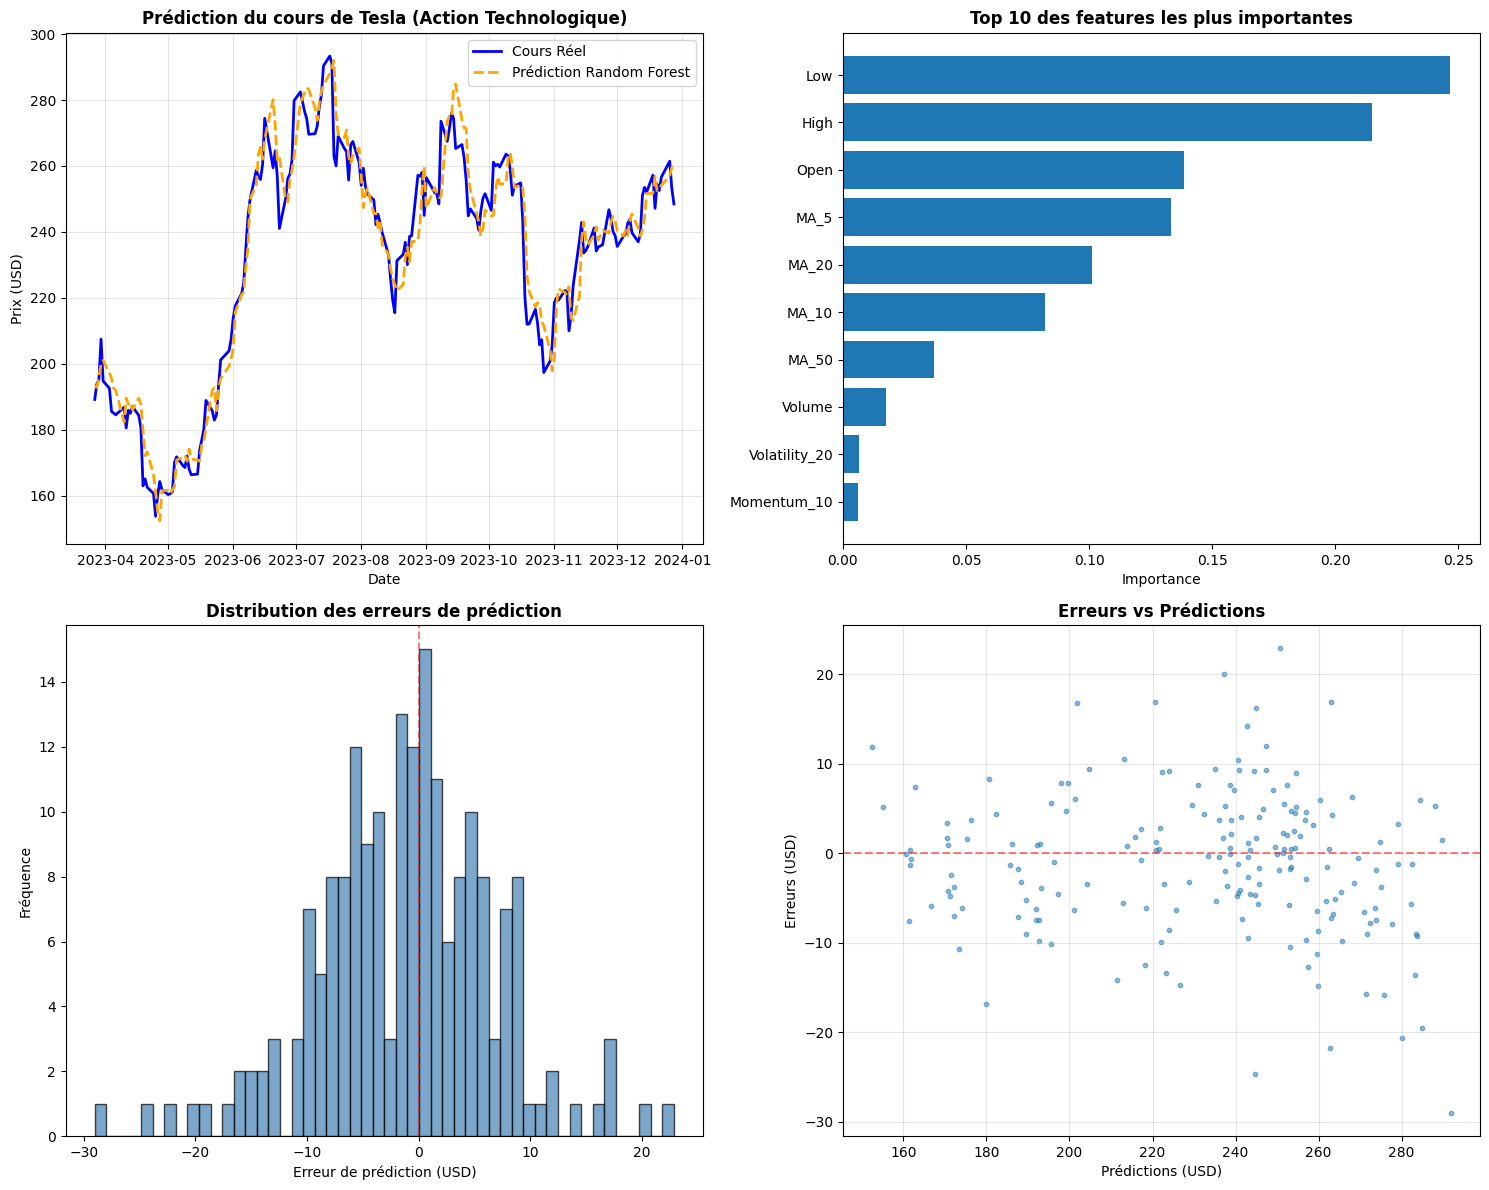


ANALYSE COMPLÉMENTAIRE

Statistiques des erreurs de prédiction :
  Erreur moyenne : -1.11 USD
  Écart-type des erreurs : 7.99 USD
  Erreur maximale positive : 22.89 USD
  Erreur maximale négative : -29.02 USD

Performance par période :
  Précision moyenne : 97.32%
  Médiane de l'erreur absolue : 5.13 USD
  Meilleure prédiction (erreur min) : 0.03 USD
  Pire prédiction (erreur max) : 29.02 USD

CONCLUSION
✓ Le modèle Random Forest performe TRÈS BIEN sur Tesla (Action Technologique)
  R² = 0.9457 indique que le modèle explique 94.6% de la variance

Le modèle prédit le cours avec une erreur moyenne de 6.13 USD
soit une précision moyenne de 97.3%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. CHOIX DES ACTIFS
# ---------------------------------------------------------
# On peut choisir différents types d'actifs pour comparer
tickers = {
    'TSLA': 'Tesla (Action Technologique)',
    'BTC-USD': 'Bitcoin (Cryptomonnaie)',
    'EURUSD=X': 'EUR/USD (Devise)',
    '^GSPC': 'S&P 500 (Indice)',
    'NVDA': 'NVIDIA (Action Semi-conducteurs)'
}

# Choix de l'actif à analyser (modifiable)
selected_ticker = 'TSLA'  # On prend Tesla pour cet exemple
ticker_name = tickers[selected_ticker]

print(f"=== Analyse de l'actif : {ticker_name} ({selected_ticker}) ===\n")

# ---------------------------------------------------------
# 2. TÉLÉCHARGEMENT DES DONNÉES
# ---------------------------------------------------------
print(f"Téléchargement des données pour {selected_ticker}...")
data = yf.download(selected_ticker, start="2020-01-01", end="2023-12-31", progress=False)

# Gestion des colonnes
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Vérification des données manquantes
data.dropna(inplace=True)

print(f"Données téléchargées : {len(data)} lignes.")
print(f"Période : du {data.index[0].date()} au {data.index[-1].date()}")
print(f"Données récentes :\n{data.tail()}\n")

# ---------------------------------------------------------
# 3. PRÉPARATION DES DONNÉES
# ---------------------------------------------------------
# Variable cible : le cours de clôture du JOUR SUIVANT
data['Target'] = data['Close'].shift(-1)
data = data[:-1]  # Supprimer la dernière ligne sans cible

# Création des features techniques
print("Création des features techniques...")

# Features de base
features = ['Open', 'High', 'Low', 'Volume']

# Moyennes mobiles
data['MA_5'] = data['Close'].rolling(window=5).mean()
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()
data['MA_50'] = data['Close'].rolling(window=50).mean()

# Indicateurs de tendance
data['MA_5_10_ratio'] = data['MA_5'] / data['MA_10']
data['MA_10_20_ratio'] = data['MA_10'] / data['MA_20']

# Volatilité
data['Returns'] = data['Close'].pct_change()
data['Volatility_5'] = data['Returns'].rolling(window=5).std()
data['Volatility_20'] = data['Returns'].rolling(window=20).std()

# Range et position
data['Range'] = (data['High'] - data['Low']) / data['Close']
data['Position'] = (data['Close'] - data['Low']) / (data['High'] - data['Low'])

# Momentum
data['Momentum_5'] = data['Close'] - data['Close'].shift(5)
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)
data['Momentum_20'] = data['Close'] - data['Close'].shift(20)

# RSI simplifié
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI_14'] = calculate_rsi(data)

# Ajout des nouvelles features
additional_features = [
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'MA_5_10_ratio', 'MA_10_20_ratio',
    'Volatility_5', 'Volatility_20',
    'Range', 'Position',
    'Momentum_5', 'Momentum_10', 'Momentum_20',
    'RSI_14'
]
features.extend(additional_features)

# Suppression des valeurs NaN
data.dropna(inplace=True)

X = data[features]
y = data['Target']

print(f"Nombre de features : {len(features)}")
print(f"Taille du dataset après nettoyage : {len(data)} lignes\n")

# ---------------------------------------------------------
# 4. SÉPARATION DES DONNÉES
# ---------------------------------------------------------
# On utilise les 80% premières données pour l'entraînement,
# les 20% dernières pour le test (prédiction future)
train_size = int(0.8 * len(data))
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print(f"Données d'entraînement : {len(X_train)} lignes")
print(f"Données de test : {len(X_test)} lignes")
print(f"Période de test : du {X_test.index[0].date()} au {X_test.index[-1].date()}\n")

# ---------------------------------------------------------
# 5. ENTRAÎNEMENT DU MODÈLE RANDOM FOREST
# ---------------------------------------------------------
print("Entraînement du modèle Random Forest...")

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 6. ÉVALUATION ET PRÉDICTIONS
# ---------------------------------------------------------
predictions = model.predict(X_test)

# Métriques
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("\n" + "="*50)
print("RÉSULTATS DU MODÈLE")
print("="*50)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Racine de l'Erreur Quadratique Moyenne (RMSE) : {rmse:.2f} USD")
print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f} USD")
print(f"Erreur Absolue Moyenne en Pourcentage (MAPE) : {mape:.2f}%")
print(f"Coefficient de détermination (R²) : {r2:.4f}")

# ---------------------------------------------------------
# 7. IMPORTANCE DES FEATURES
# ---------------------------------------------------------
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 DES FEATURES LES PLUS IMPORTANTES")
print("="*50)
for i, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:<20} : {row['importance']:.4f}")

# ---------------------------------------------------------
# 8. VISUALISATIONS
# ---------------------------------------------------------
# 8.1 Comparaison prédictions vs réel
results_df = pd.DataFrame({
    'Date': X_test.index,
    'Réel': y_test,
    'Prédit': predictions
})
results_df.sort_index(inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique principal
ax1 = axes[0, 0]
ax1.plot(results_df['Date'], results_df['Réel'], label='Cours Réel', color='blue', linewidth=2)
ax1.plot(results_df['Date'], results_df['Prédit'], label='Prédiction Random Forest', color='orange', linestyle='--', linewidth=2)
ax1.set_title(f'Prédiction du cours de {ticker_name}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Prix (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 8.2 Importance des features
ax2 = axes[0, 1]
top_features = feature_importance.head(10)
ax2.barh(range(len(top_features)), top_features['importance'].values)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['feature'].values)
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 des features les plus importantes', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# 8.3 Distribution des erreurs
ax3 = axes[1, 0]
errors = y_test - predictions
ax3.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.set_xlabel('Erreur de prédiction (USD)')
ax3.set_ylabel('Fréquence')
ax3.set_title('Distribution des erreurs de prédiction', fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 8.4 Erreurs vs Prédictions
ax4 = axes[1, 1]
ax4.scatter(predictions, errors, alpha=0.5, s=10)
ax4.set_xlabel('Prédictions (USD)')
ax4.set_ylabel('Erreurs (USD)')
ax4.set_title('Erreurs vs Prédictions', fontsize=12, fontweight='bold')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. ANALYSE COMPLÉMENTAIRE
# ---------------------------------------------------------
print("\n" + "="*50)
print("ANALYSE COMPLÉMENTAIRE")
print("="*50)

# Statistiques des erreurs
print(f"\nStatistiques des erreurs de prédiction :")
print(f"  Erreur moyenne : {errors.mean():.2f} USD")
print(f"  Écart-type des erreurs : {errors.std():.2f} USD")
print(f"  Erreur maximale positive : {errors.max():.2f} USD")
print(f"  Erreur maximale négative : {errors.min():.2f} USD")

# Métriques par période
print(f"\nPerformance par période :")
results_df['Erreur_abs'] = np.abs(results_df['Réel'] - results_df['Prédit'])
results_df['Erreur_pct'] = (results_df['Erreur_abs'] / results_df['Réel']) * 100

print(f"  Précision moyenne : {100 - results_df['Erreur_pct'].mean():.2f}%")
print(f"  Médiane de l'erreur absolue : {results_df['Erreur_abs'].median():.2f} USD")
print(f"  Meilleure prédiction (erreur min) : {results_df['Erreur_abs'].min():.2f} USD")
print(f"  Pire prédiction (erreur max) : {results_df['Erreur_abs'].max():.2f} USD")

# ---------------------------------------------------------
# 10. CONCLUSION
# ---------------------------------------------------------
print("\n" + "="*50)
print("CONCLUSION")
print("="*50)
if r2 > 0.9:
    print(f"✓ Le modèle Random Forest performe TRÈS BIEN sur {ticker_name}")
    print(f"  R² = {r2:.4f} indique que le modèle explique {r2*100:.1f}% de la variance")
elif r2 > 0.7:
    print(f"✓ Le modèle Random Forest performe BIEN sur {ticker_name}")
    print(f"  R² = {r2:.4f} indique que le modèle explique {r2*100:.1f}% de la variance")
else:
    print(f"⚠ Le modèle Random Forest performe MODÉRÉMENT sur {ticker_name}")
    print(f"  R² = {r2:.4f} suggère que le modèle pourrait être amélioré")

print(f"\nLe modèle prédit le cours avec une erreur moyenne de {mae:.2f} USD")
print(f"soit une précision moyenne de {100 - mape:.1f}%")